# Session 2.4 : Exploratory Data Analysis and Visualisation

_Analytics Through Coding Autumn 2026_

---

Visualisation is an important part of exploratory data analysis.

The aim is not simply to produce charts. We want to use **numerical summaries and visualisations together** to understand:

* distributions;
* differences between groups;
* relationships between variables;
* trends over time.

A useful workflow is:

> **Question → numerical summary → visualisation → interpretation**

We will continue using the **London Bikes** dataset.

---

## Starting out

Import the required libraries and load the data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bikes = pd.read_csv("../Data/london_bikes.csv")

# Convert date to datetime
bikes["date"] = pd.to_datetime(bikes["date"])

# Create useful date variables
bikes["year"] = bikes["date"].dt.year
bikes["month"] = bikes["date"].dt.month
bikes["month_name"] = bikes["date"].dt.month_name()
bikes["day"] = bikes["date"].dt.day
bikes["day_of_week"] = bikes["date"].dt.day_name()

# Create season
bikes["season"] = np.select(
    [
        bikes["month"].isin([12, 1, 2]),
        bikes["month"].isin([3, 4, 5]),
        bikes["month"].isin([6, 7, 8]),
        bikes["month"].isin([9, 10, 11])
    ],
    ["Winter", "Spring", "Summer", "Autumn"],
    default="Unknown"
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
bikes["season"] = pd.Categorical(
    bikes["season"],
    categories=season_order,
    ordered=True
)

bikes.head()

,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,...,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend,month_name,day,day_of_week,season
0,2010-07-30 00:00:00+00:00,6897,2010,Fri,7,30,6.0,65.0,10147.0,157.0,...,NaN,31.0,17.7,12.3,25.1,False,July,30,Friday,Summer
1,2010-07-31 00:00:00+00:00,5564,2010,Sat,7,30,5.0,70.0,10116.0,184.0,...,NaN,47.0,21.1,17.0,23.9,True,July,31,Saturday,Summer
2,2010-08-01 00:00:00+00:00,4303,2010,Sun,8,30,7.0,63.0,10132.0,89.0,...,NaN,3.0,19.3,14.6,23.4,True,August,1,Sunday,Summer
3,2010-08-02 00:00:00+00:00,6642,2010,Mon,8,31,7.0,59.0,10168.0,134.0,...,NaN,20.0,19.5,15.6,23.6,False,August,2,Monday,Summer
4,2010-08-03 00:00:00+00:00,7966,2010,Tue,8,31,5.0,66.0,10157.0,169.0,...,NaN,39.0,17.9,12.1,20.1,False,August,3,Tuesday,Summer


## First look: numerical exploration

Before choosing a chart, first understand the variables we have.

Useful first questions include:

* How many observations are there?
* What does one row represent?
* Which variables are numerical and categorical?
* Are important values missing?
* What are the typical values and ranges?

We already developed these habits in Session 1. Here we apply them specifically to exploratory analysis.

### Exercise 1 — Numerical summaries

Using the bikes dataset:

1. Find the mean and median number of bikes hired per day.
2. Find the minimum and maximum number of bikes hired.
3. Calculate the mean number of bikes hired within each season.
4. Calculate the number of observations within each season.

Store the grouped summary in a DataFrame called `season_summary`.

## Choosing a visualisation

Different analytical questions call for different visual forms.

| Analytical question | Useful visualisation |
|---|---|
| What does one numerical variable look like? | Histogram |
| How does a numerical variable differ across groups? | Boxplot |
| Are two numerical variables related? | Scatterplot |
| How does a variable change over time? | Time-series / line plot |

The chart type should follow the **question**, not the other way around.

### Exercise 2 — Which chart would you choose?

Choose the most appropriate chart for each question:

1. What does the distribution of daily bike hires look like?
2. Do bike hires differ across seasons?
3. Is temperature associated with bike hires?
4. How have bike hires changed over time?

**Solution**

1. Distribution of daily bike hires → **Histogram**
2. Bike hires across seasons → **Boxplot**
3. Temperature and bike hires → **Scatterplot**
4. Bike hires over time → **Time-series / line plot**

# 1. Distribution

## Question: What does the distribution of daily bike hires look like?

A histogram divides a numerical variable into intervals and shows how many observations fall into each interval.

Before plotting, numerical summaries give us some useful context.

### Interpret the plot

When looking at a distribution, ask:

* Where is the centre of the distribution?
* How spread out are the observations?
* Is the distribution symmetric or skewed?
* Are there unusually high or low values?
* Does the visual pattern agree with the numerical summary?

A chart should lead to an interpretation, not simply be the end of the analysis.

### Exercise 3 — Distribution of temperature

Create a histogram of `mean_temp`.

Use approximately 25 bins and include:

* a meaningful title;
* an x-axis label;
* a y-axis label.

Then describe the broad shape of the distribution.

# 2. Comparison across groups

## Question: Do bike hires differ across seasons?

A boxplot is useful when we want to compare the distribution of a numerical variable across categories.

The line inside each box represents the median. The box captures the middle part of the distribution, while points beyond the whiskers may indicate unusual observations.

### Think about the result

The grouped summary and the boxplot answer related but different questions.

The table gives us precise numerical summaries.

The boxplot shows:

* the centre;
* spread;
* overlap between groups;
* unusual observations.

Whenever possible, use the two together.

### Exercise 4 — Weekday versus weekend

Compare daily bike hires between weekdays and weekends.

1. Calculate the mean and median `bikes_hired` for `weekend = True` and `weekend = False`.
2. Create a boxplot comparing the two groups.
3. Think about whether a difference in the chart is enough to conclude that weekends *cause* the difference.

<div class="alert alert-warning">
<b>Interpretation note.</b>

A difference between groups is a descriptive pattern in the data.

The chart does not, by itself, establish that being a weekend <i>causes</i> the observed difference. Other factors may vary at the same time.
</div>

# 3. Relationship between numerical variables

## Question: Is temperature associated with bike hires?

A scatterplot is useful when both variables are numerical.

Each point represents one observation — here, one day.

When interpreting a scatterplot, ask:

* Is there a positive or negative association?
* Is the relationship roughly linear?
* How much variation is there around the pattern?
* Are there unusual observations?
* Could another variable be influencing both variables?

Again, **association is not the same as causation**.

### Exercise 5 — Humidity and bike hires

Create a scatterplot showing the relationship between:

* `humidity`
* `bikes_hired`

Then answer:

1. Does the plot suggest a positive, negative or weak association?
2. Is there substantial variation around the pattern?
3. Would this plot alone justify a causal statement?

# 4. Trends over time

## Question: How have bike hires changed over time?

Time is ordered, so a line-based visualisation is usually more useful than treating dates as unrelated categories.

Daily observations can be noisy. A rolling average helps us see the underlying trend without removing the original data.

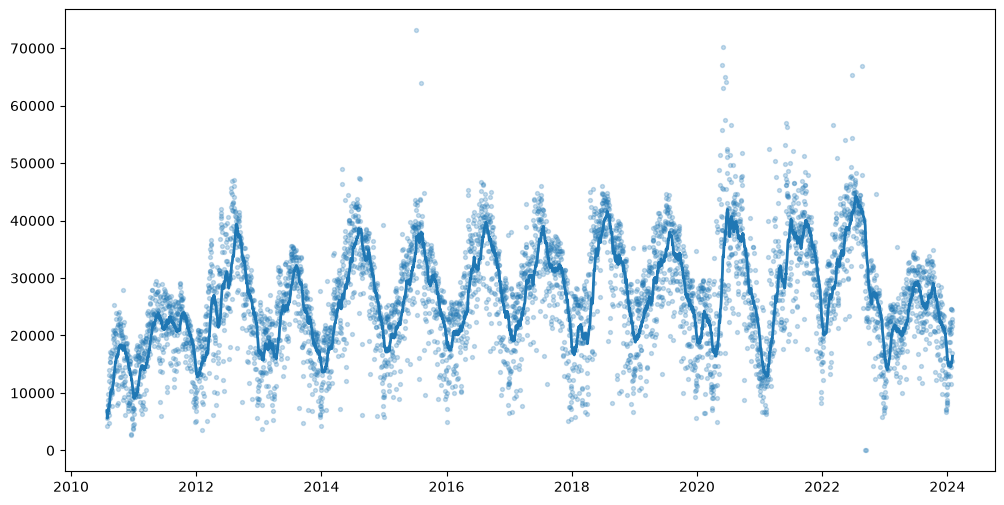

In [6]:
bikes_sorted = bikes.sort_values(by="date").copy()
bikes_sorted["trend_38d"] = (
    bikes_sorted["bikes_hired"]
    .rolling(38, min_periods=1)
    .mean()
)
plt.figure(figsize=(12, 6))

plt.scatter(
    bikes_sorted["date"],
    bikes_sorted["bikes_hired"],
    alpha=0.25,
    s=8
    
)
plt.plot(
    bikes_sorted["date"],
    bikes_sorted["trend_38d"],
    linewidth=2,
)

### Interpretation

The raw observations show day-to-day variation.

The rolling average helps reveal slower-moving changes in the series.

Neither representation is inherently better — they answer slightly different questions:

* raw observations show daily variability;
* the rolling average makes the broader trend easier to see.

### Exercise 6 — Annual trend

Calculate the mean number of bikes hired per day for each year.

Then create a line plot of annual mean daily hires.

The resulting table should contain:

* `year`
* `mean_bikes`

Use markers so that individual yearly observations are visible.

# From technically correct to useful

A chart can run successfully and still communicate poorly.

Consider the following monthly summary.

A technically correct chart might ignore the natural ordering of months.

The code works — but the communication can be improved.

Now explicitly use the calendar order and a more informative title.

The analytical values have not changed.

What changed was the **communication**:

* categories now appear in a meaningful order;
* the title tells the reader what the chart is about;
* the axis labels describe the quantity being shown.

A technically valid chart is not automatically an effective chart.

# Final Exercise — Explore a business question

## Do weekdays and weekends show different patterns across seasons?

Use both numerical summaries and a visualisation.

1. Group the data by `season` and `weekend`.
2. Calculate:
   * mean bike hires;
   * median bike hires;
   * number of observations.
3. Create a boxplot of `bikes_hired` by `season`, using `weekend` to distinguish the two groups.
4. Write down **two patterns supported directly by the data**.
5. Write down **one explanation that would require additional evidence before you could claim it**.

**Example interpretation**

Patterns that can be supported directly should refer to what is visible in the summaries or chart — for example, differences in the typical number of hires, spread, or overlap between groups.

An explanation such as:

> “The difference is caused by commuting behaviour.”

would require additional evidence. The dataset may show a pattern consistent with that explanation, but the visualisation alone does not establish the cause.

## Optional extension — Density plots

Density plots are another way to visualise a numerical distribution.

They can be useful for comparing the shape of distributions, but they are not essential for the core workflow in this session.

## All Done!

In this session we combined **exploratory data analysis and visualisation**.

We practised:

* using numerical summaries before plotting;
* selecting a visualisation based on the analytical question;
* examining distributions with histograms;
* comparing groups with boxplots;
* examining relationships with scatterplots;
* examining change over time with time-series plots;
* using rolling averages to reveal trends;
* improving a technically correct chart so that it communicates more clearly;
* separating patterns supported by the data from explanations that require additional evidence.

The key workflow is:

> **Question → numerical summary → visualisation → interpretation**

The next step is to consider how AI tools can assist with analysis — and, importantly, how we can critically check the code, evidence and conclusions they produce.